In [1]:
# type: ignore
import numpy as np
import custom_lib as cl 
import random
import gc
import torch
import torch.nn as nn
import torch.optim as optim # type: ignore
from torchvision import datasets, transforms

In [2]:
## Definicion de la arquitectura del modelo
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(28*28, 20) #hidden layer 1
        self.relu = nn.ReLU() #funcion de activacion relu
        self.fc2 = nn.Linear(20, 10)  #hidden layer 2
        self.softmax = nn.Sigmoid()
    
    def forward(self, x):
        x = x.view(-1, 28*28) #el -1 hace que esa primera dimension se autoajuste en funcion de las otras
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x


In [3]:
# Carga de los datos
transform = transforms.ToTensor()
train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

In [18]:
# Procesado de los datos
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

In [5]:
# Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = NeuralNetwork().to(device) #este es el nombre de mi modelo
print(device)

cuda


In [6]:
# Optimozador y funcion de perdida
optimizer = optim.Adam(network.parameters(), lr=0.01, betas=(0.9, 0.99))
loss_criterion = nn.CrossEntropyLoss()

In [7]:
# Funcion de entrenamiento
def train(network, device, train_loader, optimizer, epoch):
    network.train()
    for batch_id, (data, label) in enumerate(train_loader):
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad()
        output = network(data)
        loss = loss_criterion(output, label)
        loss.backward()
        optimizer.step()
        if batch_id % 100 == 0:
            print(f"Epoch {epoch} [{batch_id * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():6f}")

In [8]:
# Funcion de testeo
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_criterion(output, target).item()  # Suma de la pérdida
            pred = output.argmax(dim=1, keepdim=True)        # Predicción: índice de la clase mayor probabilidad
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    accuaracy = 100. * correct / len(test_loader.dataset)
    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n")
    return accuaracy

In [19]:
epochs = 10
model_precision = torch.zeros(epochs)
epochs_vect = torch.zeros(epochs)
print(model_precision)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [20]:
for epoch in range(1, epochs+1):
    train(network, device, train_loader, optimizer, epoch)
    print(epoch)
    model_precision[epoch-1] = test(network, device, test_loader)
    epochs_vect[epoch-1] = epoch
    print(model_precision)  


Epoch 1 [0/60000] Loss: 2.307940
Epoch 1 [12800/60000] Loss: 1.563268
Epoch 1 [25600/60000] Loss: 1.556614
Epoch 1 [38400/60000] Loss: 1.538612
Epoch 1 [51200/60000] Loss: 1.511305
1

Test set: Average loss: 0.0241, Accuracy: 9206/10000 (92%)

tensor([92.0600,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000])
Epoch 2 [0/60000] Loss: 1.554200
Epoch 2 [12800/60000] Loss: 1.523303
Epoch 2 [25600/60000] Loss: 1.500570
Epoch 2 [38400/60000] Loss: 1.521428
Epoch 2 [51200/60000] Loss: 1.529907
2

Test set: Average loss: 0.0239, Accuracy: 9305/10000 (93%)

tensor([92.0600, 93.0500,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000])
Epoch 3 [0/60000] Loss: 1.522895
Epoch 3 [12800/60000] Loss: 1.534898
Epoch 3 [25600/60000] Loss: 1.507099
Epoch 3 [38400/60000] Loss: 1.554059
Epoch 3 [51200/60000] Loss: 1.506666
3

Test set: Average loss: 0.0239, Accuracy: 9328/10000 (93%)

tensor([92.0600, 93.0500, 93.2800,  0.0000,  0.0000,  

In [ ]:
print(model_precision)
print(model_precision)

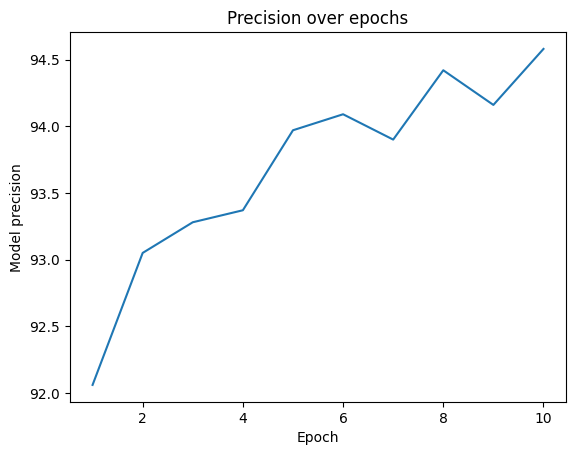

In [21]:
import matplotlib.pyplot as plt

plt.plot(epochs_vect, model_precision)
plt.xlabel("Epoch")
plt.ylabel("Model precision")
plt.title("Precision over epochs")
plt.show()

In [12]:
cl.save_model(network, "save/model_data.pth")

In [17]:
network.apply(cl.clear_cache)

<bound method Linear.reset_parameters of Linear(in_features=784, out_features=20, bias=True)>
None
<bound method Linear.reset_parameters of Linear(in_features=20, out_features=10, bias=True)>
None
None


NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (softmax): Sigmoid()
)

In [14]:
print(test(network, device, test_loader))


Test set: Average loss: 0.0362, Accuracy: 856/10000 (9%)

8.56


In [15]:
cl.load_model(network, "save/model_data.pth")

In [23]:
print(test(network, device, test_loader))


Test set: Average loss: 0.0237, Accuracy: 9458/10000 (95%)

94.58
